In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
%matplotlib inline
plt.rc('figure', figsize=(10, 6))
from matplotlib import rcParams
rcParams['font.family'] = 'Hancom Gothic'
rcParams['font.size'] = 10
rcParams['axes.unicode_minus'] = False

P(A) 사전확률 - 암 P(B) 사후확률 - 양성

P(A|B) -> P(B|A)?

베이즈의 정리 P(A|B) = P(B|A) * P(A) / P(B)

문제) 양성B 진단 -> 실제 암A일 확률은?, 진단의 정확도 95%, 암환자의 비율 10%

5% 오진 P(양성|암') = 0.05 = P(B|A')
95% 정확 P(양성|암) = 0.95 = P(B|A)
암 P(A) = 0.1 암' P(A') = 0.9

양성 P(B) = 암&양성 + 암'&양성 = 0.095 + 0.045 = 0.14 암&양성 = P(A교집합B) = P(A)P(B|A) = 0.10.95 암'&양성 = P(A'교집합B) = P(A') * P(B|A') = 0.9*0.05

베이즈의 정리 P(A|B) = P(B|A) * P(A) / P(B) = 0.95 * 0.1 /0.14 =

In [ ]:
P_A = 0.1 #암의 확률
P_not_A = 0.9 #암이 아닐 확률
P_B_given_A = 0.95 #양성판정의 정확도
P_B_given_not_A = 0.05 #암이 아닌데 양성판정을 받을 확률

P_A_given_B = P_B_given_A * P_A / ((P_B_given_A * P_A) + (P_B_given_not_A * P_not_A))
P_A_given_B

0.6785714285714285

# 확률의 계산

## 동전던지기

In [8]:
space = ['앞면', '뒷면']
event = ['앞면']

prob = lambda event, space : len(event) / len(space)
prob(event, space)

0.5

## 주사위던지기

In [9]:
# 1번 던져 3이 나올 확률
space = [1, 2, 3, 4, 5, 6]
event = [3]

prob(event, space)

0.16666666666666666

# 확률의 덧셈

## 주사위에서 짝수이거나 4보다 큰 수가 나올 확률

In [19]:
space = {1, 2, 3, 4, 5, 6}
event_A = {2, 4, 6}
event_B = {5, 6}

In [20]:
합집합 = event_A | event_B
합집합

{2, 4, 5, 6}

In [21]:
합집합의개수 = len(합집합)
전체개수 = len(space)
확률_1 = 합집합의개수 / 전체개수
확률_1

0.6666666666666666

## 2이하이거나 5이상인 눈이 나올 확률

In [23]:
space = {1, 2, 3, 4, 5, 6}
event_A = {1, 2}
event_B = {5, 6}

In [24]:
합집합 = event_A | event_B
합집합

{1, 2, 5, 6}

In [25]:
합집합의개수 = len(합집합)
전체개수 = len(space)
확률_2 = 합집합의개수 / 전체개수
확률_2

0.6666666666666666

# 확률의 교집합

## 주사위를 던져 짝수면서 2일 확률

In [ ]:
#조건부 확률
sample_space = [1, 2, 3, 4, 5, 6]
event_A = [2, 4, 6]
event_B = [2]
P_A = len(event_A) / len(sample_space) #A확률
P_B = len(event_B) / len(sample_space) #B확률
P_B_and_A_ele = set(event_A) & set(event_B) #교집합의 원소
P_B_and_A_ele

{2}

In [ ]:
P_B_and_A = len(P_B_and_A_ele) / len(sample_space)#교집합 확률
P_B_and_A

0.16666666666666666

In [30]:
# 조건부확률 : 짝수일때 2가 나올 확률
#P(B|A) = P(B_and_A) / P_A
P_B_given_A = P_B_and_A / P_A
P_B_given_A

0.3333333333333333

# 우도와 확률값

동전 10번 던지고, 8번 앞면이 나왔을때 우도의 계산

In [31]:
from scipy.stats import binom

In [32]:
n = 10
k = 8 #앞면의 횟수

#가설1 - 공정한 동전일 것이다
p1 = 0.5 #앞면이 나올 확률 - 공정할 경우
p1_likelihood = binom.pmf(k,n,p1) #조건, 총사건, 확률

#가설2 - 불공정한 동전일 것이다
p2 = 0.8 #앞면이 나올 확률 - 불공정할 경우
p2_likelihood = binom.pmf(k,n,p2) #조건, 총사건, 확률

p1_likelihood, p2_likelihood

(np.float64(0.04394531250000005), np.float64(0.30198988799999993))

가설1의 경우 앞면이 8번 나올 확률은 4.4%<br>
가설2의 경우 앞면이 8번 나올 확률은 30.2%<br>
<br>
앞면이 8번 나오는 관측값은 p=0.8인 모델이 더 잘 설명한다 (우도가 크다)

# 기대값
x의 확률들의 평균

In [33]:
x_values = [1, 2, 3]
p_x = [1/6, 3/6, 2/6]
exp_value = 0

#기대값
for i in range(len(x_values)):
    exp_value += x_values[i] * p_x[i]
    

print(f"기대값 : {exp_value:.5f}")

기대값 : 2.16667


In [39]:
from scipy.stats import norm

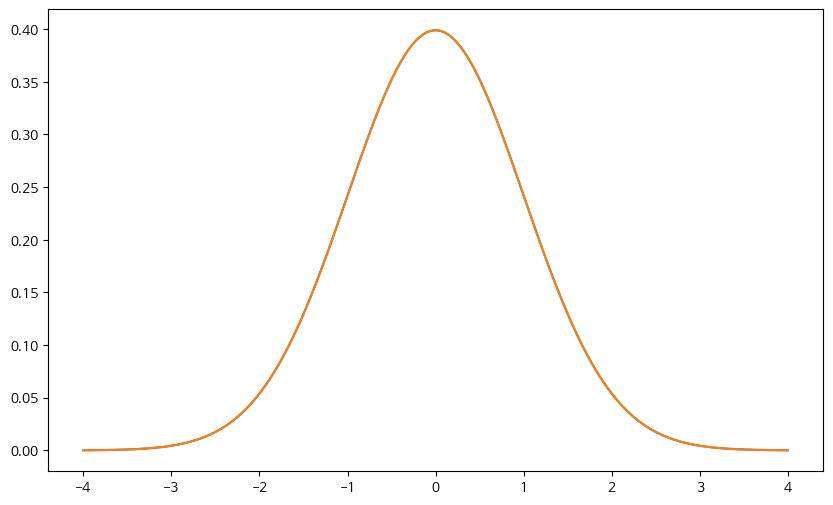

In [42]:
mu = 0
sigma = 1

x = np.linspace(-4, 4, 1000)
y = norm.pdf(x, loc = mu, scale = sigma)

plt.plot(x,y)
plt.show()

# 표집분포

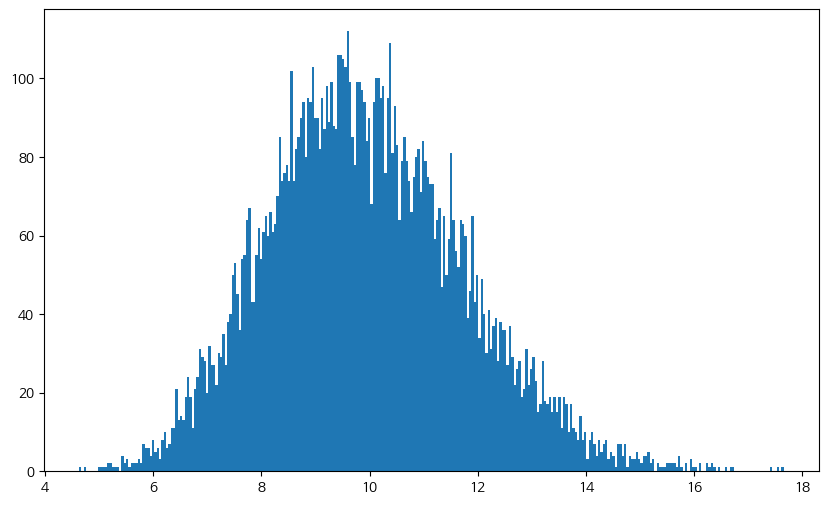

In [49]:
np.random.seed(0)
x_pop = np.random.exponential(scale=10, size=10000)
sample_mean = [np.mean(np.random.choice(x_pop, size=30))
               for i in range(10000)]

plt.hist(sample_mean, bins=300)
plt.show()

# z점수

In [55]:
mu = 100
sigma = 10

x1 = 110 #z점수를 계산하려고 하는 원래 점수
x2 = 125

#z점수 = (원점수 - 평균)/ 표준편차
z_x1 = (x1 -mu) / sigma
z_x2 = (x2 -mu) / sigma
z_x1, z_x2

(1.0, 2.5)

z_x1 = 0.8413 -> 0.5 -> 0.3413
z_x2 = 0.9938 -> 0.5 -> 0.4938

0.4938 - 0.1413 = 0.1525 15%

전체 분포에서 x1~x2 사이의 면적

In [51]:
area_z_x1 = norm.cdf(z_x1) - norm.cdf(0)
area_z_x2 = norm.cdf(z_x2) - norm.cdf(0)
diff_area = area_z_x2 - area_z_x1
diff_area

np.float64(0.15244558860568092)

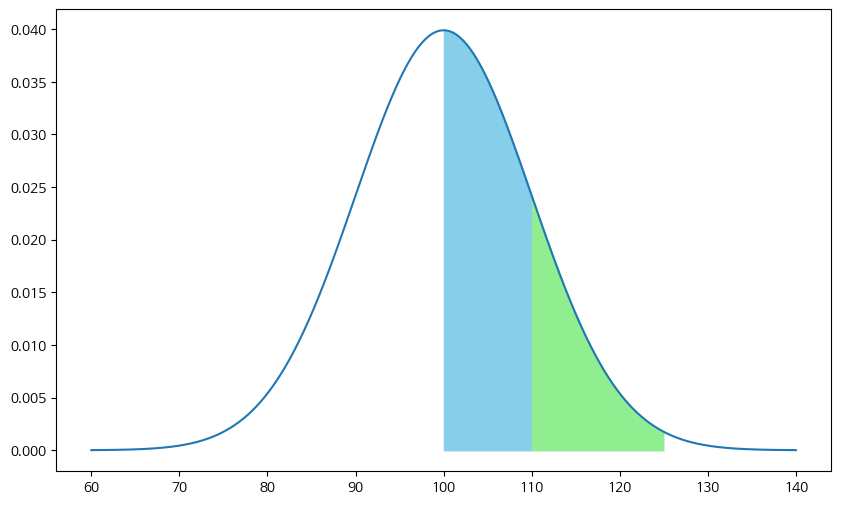

In [61]:
# 시각화
x = np.linspace(mu-4*sigma, mu+4*sigma, 1000)
y = norm.pdf(x, mu, sigma)
plt.plot(x,y)
plt.fill_between(x,y, where=(x>=100)&(x<=110), color='skyblue')
plt.fill_between(x,y, where=(x>110)&(x<=125), color='lightgreen')
plt.show()

In [67]:
# 기대값
data = {
    '상금' : [0,100,1000], #X
    '확률' : [0.5,0.3,0.2] #f(X)
}

df = pd.DataFrame(data)
df['exp_value'] = df['상금'] * df['확률']
print(f'복권의 기대값 : {df['exp_value'].sum()}원')

복권의 기대값 : 230.0원


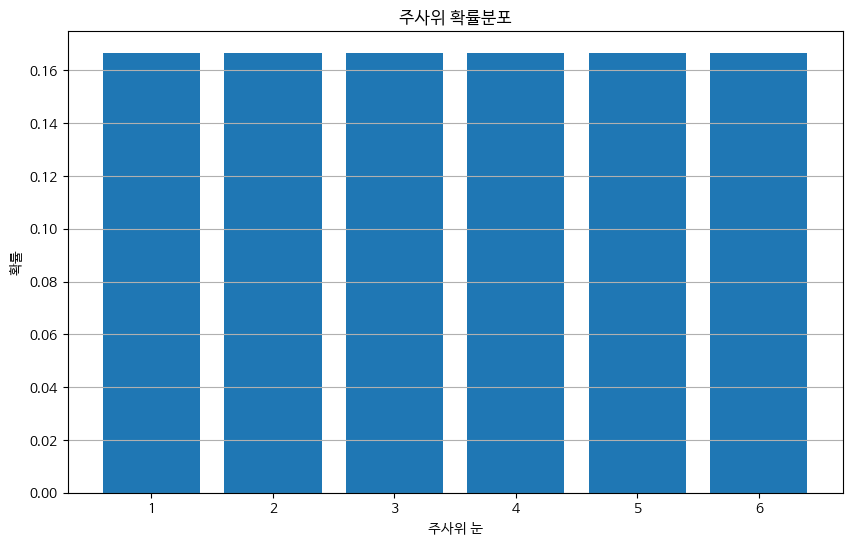

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# 주사위 눈 (1~6)
x = np.arange(1, 7)
# 공정한 주사위의 확률분포: 모두 1/6
probs = [1/6] * 6  #6을 곱하는 이유는  6번 반복해서 리스트로 만든다는 의미 - 각 눈별로 확률이 동일하므로 모두 1/6로 설정

# 시각화
plt.rc('figure', figsize=(10, 6))
plt.bar(x, probs)
plt.xticks(x)
plt.xlabel("주사위 눈")
plt.ylabel("확률")
plt.title("주사위 확률분포")
plt.grid(axis='y')
plt.show()

In [70]:
# 베르누이 분포 예시 - 동전 던지기
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bernoulli

# 베르누이 분포 파라미터 설정
p = 0.5  # 앞면이 나올 확률

# 베르누이 확률변수 생성
X = bernoulli(p)

In [75]:
result = X.rvs(size=1)
print(f"동전 1회 던지기 결과: {'앞면' if result[0] == 1 else '뒷면'}")

동전 1회 던지기 결과: 앞면


In [79]:
# 여러 번 시행 결과 시뮬레이션
n_trials = 1000
results = X.rvs(size=n_trials)

In [80]:
# 결과 분석
success_count = np.sum(results)
success_rate = success_count / n_trials

print(f"1000번 던졌을 때 앞면 나온 횟수: {success_count}")
print(f"앞면 나올 확률 (이론값: {p}, 실험값: {success_rate:.4f})")

1000번 던졌을 때 앞면 나온 횟수: 472
앞면 나올 확률 (이론값: 0.5, 실험값: 0.4720)


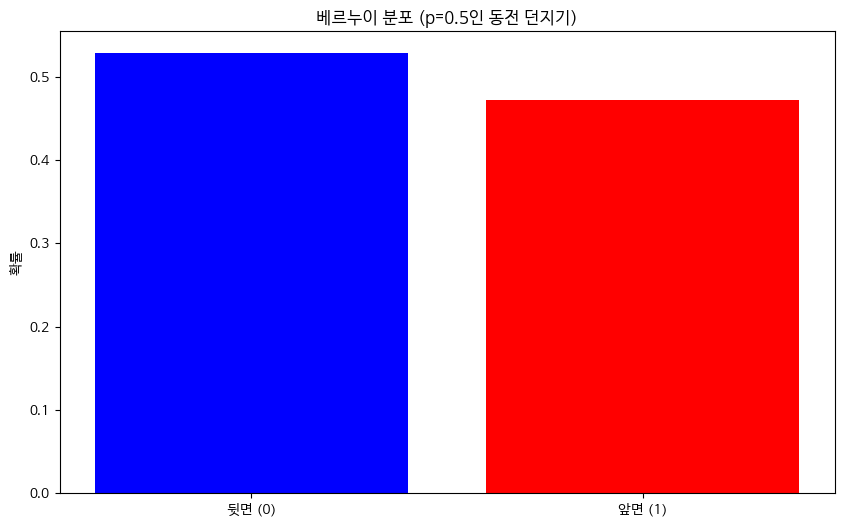

In [82]:
# 시각화
plt.figure(figsize=(10, 6))
plt.bar([0, 1], [1-success_rate, success_rate], color=['blue', 'red'])
plt.xticks([0, 1], ['뒷면 (0)', '앞면 (1)'])
plt.ylabel('확률')
plt.title('베르누이 분포 (p=0.5인 동전 던지기)')
plt.show()


In [102]:
# 이항 분포 파라미터 설정
n = 10  # 시행 횟수
p = 0.5  # 성공 확률(동전 앞면이 나올 확률)

# 이항 확률변수 생성
X = binom(n, p)

# 가능한 모든 결과값(0부터 n까지)
k_values = np.arange(0, n+1)

# 각 결과값의 확률 계산
pmf_values = X.pmf(k_values)

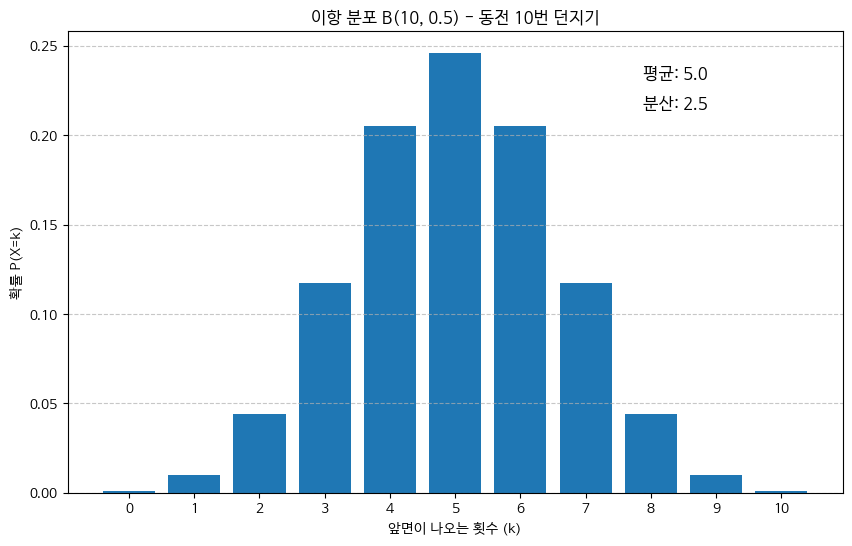

In [93]:
# 결과 시각화
plt.figure(figsize=(10, 6))
plt.bar(k_values, pmf_values)
plt.xlabel('앞면이 나오는 횟수 (k)')
plt.ylabel('확률 P(X=k)')
plt.title(f'이항 분포 B({n}, {p}) - 동전 10번 던지기')
plt.xticks(k_values)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 평균과 분산 출력
mean = n * p
var = n * p * (1-p)
plt.figtext(0.7, 0.8, f'평균: {mean}', fontsize=12)
plt.figtext(0.7, 0.75, f'분산: {var}', fontsize=12)

plt.show()

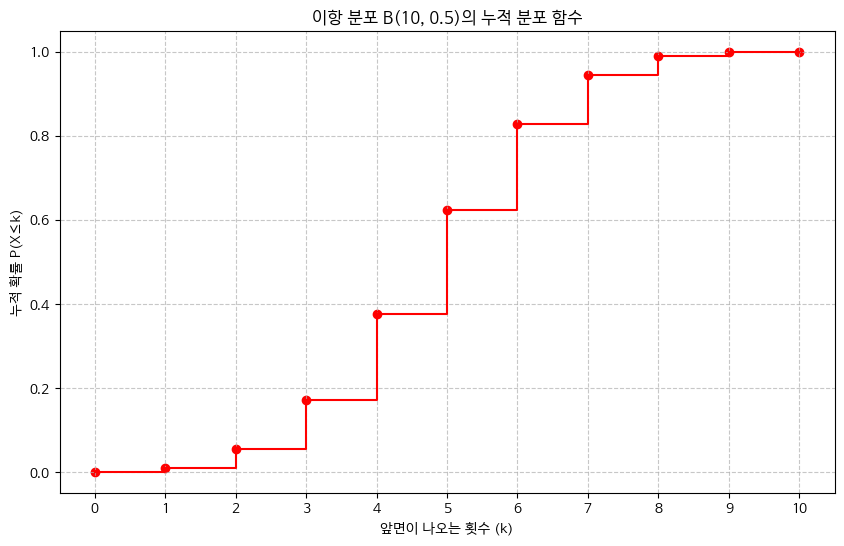

In [94]:
# 누적 분포 함수(CDF) 계산 및 시각화
cdf_values = X.cdf(k_values)

plt.figure(figsize=(10, 6))
plt.step(k_values, cdf_values, where='post', color='red')
plt.scatter(k_values, cdf_values, color='red')
plt.xlabel('앞면이 나오는 횟수 (k)')
plt.ylabel('누적 확률 P(X≤k)')
plt.title(f'이항 분포 B({n}, {p})의 누적 분포 함수')
plt.xticks(k_values)
plt.grid(linestyle='--', alpha=0.7)
plt.show()

# 이항분포를 적용할 수 있는 사례

1. 시험 합격률이 70%, 100명일때 80명이상 합격할 확률
2. 불량률 5%, 20개 샘플일때 불량제품이 2개 이하일 확률

총 응시자 수: 100명
개별 합격률: 70%
100명 중 80명 이상 합격할 확률: 0.0165


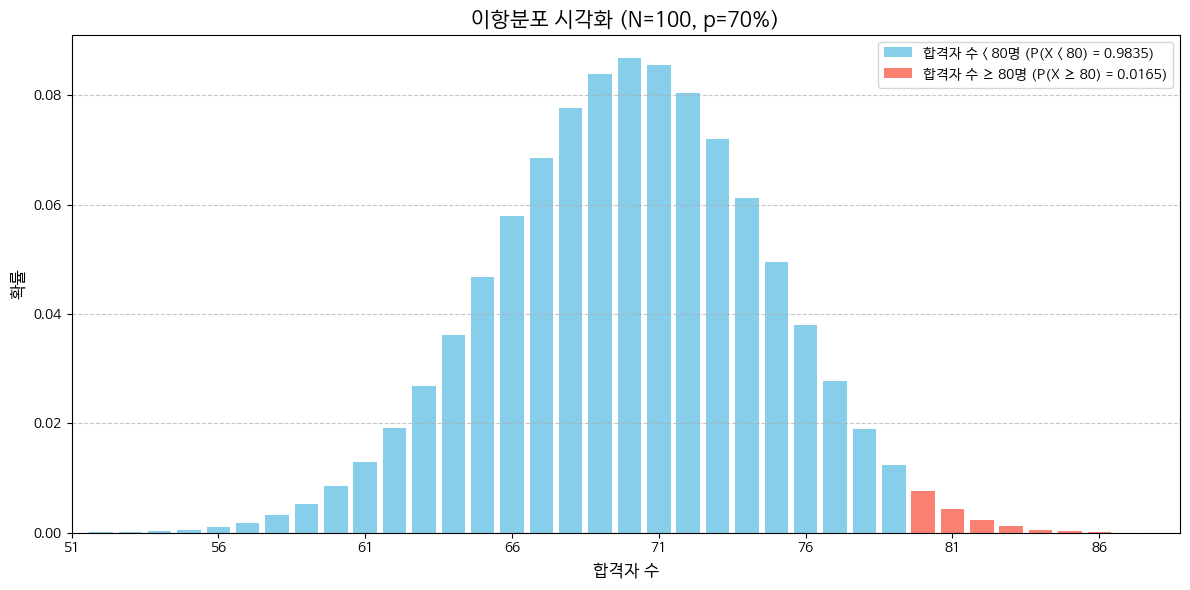

In [113]:
# N: 총 시험 응시자 수 (시행 횟수)
N = 100
# p: 한 명의 시험 합격률 (성공 확률)
p = 0.7

# k: 합격자 수 (80명 이상이므로 80부터 N까지)

# 이항분포에서 P(X >= k)를 계산하려면 1 - P(X < k)를 사용합니다.
# 즉, 1 - P(X <= k-1)
# 여기서는 P(X >= 80)을 구해야 하므로, 1 - P(X <= 79)를 계산합니다.
probability_at_least_80 = 1 - stats.binom.cdf(79, N, p)

print(f"총 응시자 수: {N}명")
print(f"개별 합격률: {p*100:.0f}%")
print(f"{N}명 중 {80}명 이상 합격할 확률: {probability_at_least_80:.4f}")

# --- 시각화 부분 ---

# 가능한 합격자 수 (0부터 N까지)
x = np.arange(0, N + 1)
# 각 합격자 수에 대한 확률 질량 함수 (PMF) 계산
pmf = stats.binom.pmf(x, N, p)

plt.figure(figsize=(12, 6)) # 그래프 크기 설정

# 막대 그래프 그리기
# 80명 미만인 경우 파란색
plt.bar(x[x < 80], pmf[x < 80], color='skyblue', label=f'합격자 수 < 80명 (P(X < 80) = {stats.binom.cdf(79, N, p):.4f})')
# 80명 이상인 경우 주황색으로 강조
plt.bar(x[x >= 80], pmf[x >= 80], color='salmon', label=f'합격자 수 ≥ 80명 (P(X ≥ 80) = {probability_at_least_80:.4f})')

# 그래프 제목 및 축 레이블 설정
plt.title(f'이항분포 시각화 (N={N}, p={p*100:.0f}%)', fontsize=15)
plt.xlabel('합격자 수', fontsize=12)
plt.ylabel('확률', fontsize=12)

# x축 범위 설정 (관심 있는 부분 주변을 더 자세히 보기 위해)
plt.xlim(N * p - 3 * np.sqrt(N * p * (1-p)) - 5, N * p + 3 * np.sqrt(N * p * (1-p)) + 5)
plt.xticks(np.arange(int(N * p - 3 * np.sqrt(N * p * (1-p)) - 5), int(N * p + 3 * np.sqrt(N * p * (1-p)) + 5), 5))


plt.grid(axis='y', linestyle='--', alpha=0.7) # 그리드 추가
plt.legend(fontsize=10) # 범례 추가
plt.tight_layout() # 레이아웃 자동 조정
plt.show() # 그래프 표시

총 샘플 수: 20개
불량률: 5%
20개 샘플 중 불량 제품이 2개 이하일 확률: 0.9245


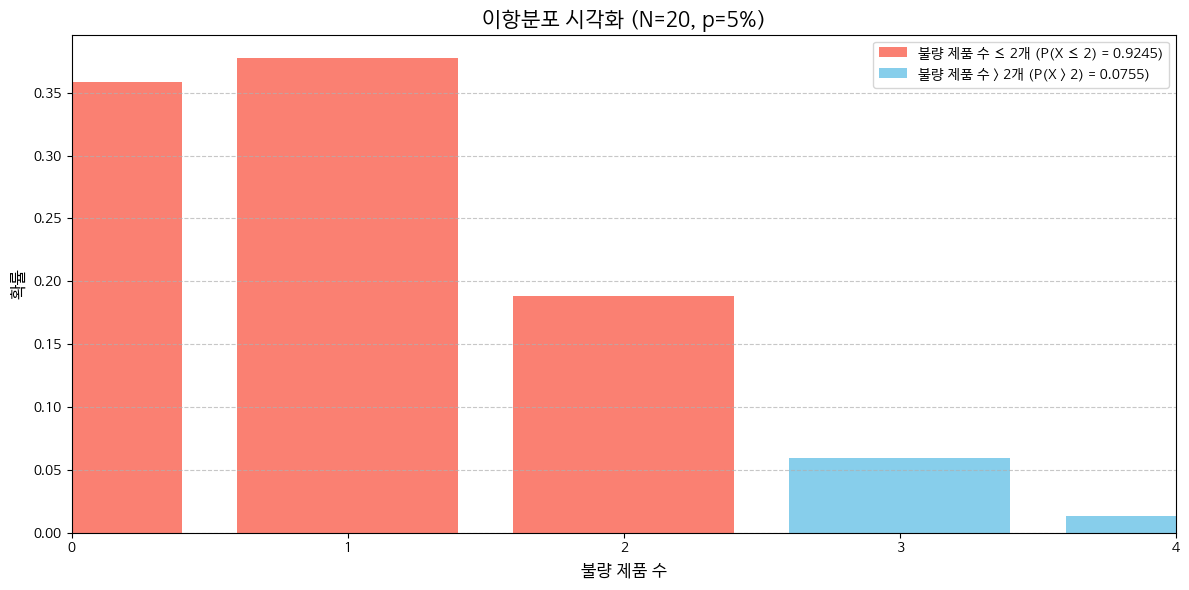

In [114]:
# N: 총 샘플 수 (시행 횟수)
N = 20
# p: 불량률 (성공 확률 - 여기서는 불량을 '성공'으로 간주)
p = 0.05

# k: 불량 제품 수 (2개 이하이므로 0, 1, 2)

# 이항분포에서 P(X <= k)를 계산하려면 cdf를 직접 사용합니다.
# 여기서는 P(X <= 2)를 구해야 하므로, binom.cdf(2, N, p)를 계산합니다.
probability_at_most_2_defective = stats.binom.cdf(2, N, p)

print(f"총 샘플 수: {N}개")
print(f"불량률: {p*100:.0f}%")
print(f"{N}개 샘플 중 불량 제품이 {2}개 이하일 확률: {probability_at_most_2_defective:.4f}")

# --- 시각화 부분 ---

# 가능한 불량 제품 수 (0부터 N까지)
x = np.arange(0, N + 1)
# 각 불량 제품 수에 대한 확률 질량 함수 (PMF) 계산
pmf = stats.binom.pmf(x, N, p)

plt.figure(figsize=(12, 6)) # 그래프 크기 설정

# 막대 그래프 그리기
# 불량 제품이 2개 이하인 경우 주황색으로 강조
plt.bar(x[x <= 2], pmf[x <= 2], color='salmon', label=f'불량 제품 수 ≤ 2개 (P(X ≤ 2) = {probability_at_most_2_defective:.4f})')
# 불량 제품이 2개 초과인 경우 파란색
plt.bar(x[x > 2], pmf[x > 2], color='skyblue', label=f'불량 제품 수 > 2개 (P(X > 2) = {1 - probability_at_most_2_defective:.4f})')


# 그래프 제목 및 축 레이블 설정
plt.title(f'이항분포 시각화 (N={N}, p={p*100:.0f}%)', fontsize=15)
plt.xlabel('불량 제품 수', fontsize=12)
plt.ylabel('확률', fontsize=12)

# x축 범위 설정 (관심 있는 부분 주변을 더 자세히 보기 위해)
# N*p는 평균, np.sqrt(N*p*(1-p))는 표준편차
mean = N * p
std_dev = np.sqrt(N * p * (1-p))
plt.xlim(max(0, int(mean - 3 * std_dev) - 1), min(N, int(mean + 3 * std_dev) + 1))
plt.xticks(np.arange(max(0, int(mean - 3 * std_dev) - 1), min(N, int(mean + 3 * std_dev) + 2), 1))


plt.grid(axis='y', linestyle='--', alpha=0.7) # 그리드 추가
plt.legend(fontsize=10) # 범례 추가
plt.tight_layout() # 레이아웃 자동 조정
plt.show() # 그래프 표시

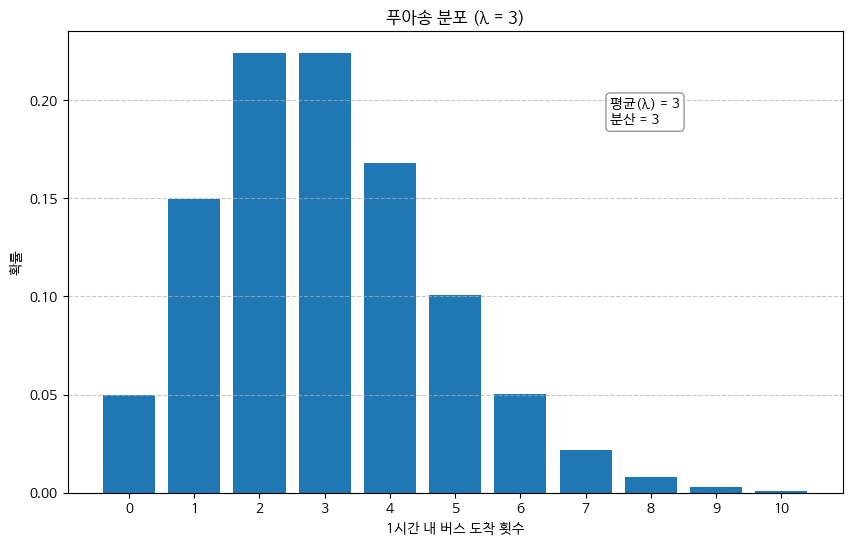

In [111]:
# 푸아송 분포 - 버스 도착 시뮬레이션
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# 파라미터 설정
lambda_val = 3  # 1시간당 평균 버스 도착 횟수

# 푸아송 확률변수 생성
X = poisson(lambda_val)

# 가능한 버스 도착 횟수 (0부터 10까지)
k_values = np.arange(0, 11)

# 각 값에 대한 확률 계산
pmf_values = X.pmf(k_values)

# 결과 시각화
plt.figure(figsize=(10, 6))
plt.bar(k_values, pmf_values)
plt.xlabel('1시간 내 버스 도착 횟수')
plt.ylabel('확률')
plt.title(f'푸아송 분포 (λ = {lambda_val})')
plt.xticks(k_values)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 평균과 분산 표시
plt.annotate(f'평균(λ) = {lambda_val}\n분산 = {lambda_val}', 
             xy=(0.7, 0.8), xycoords='axes fraction',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.show()



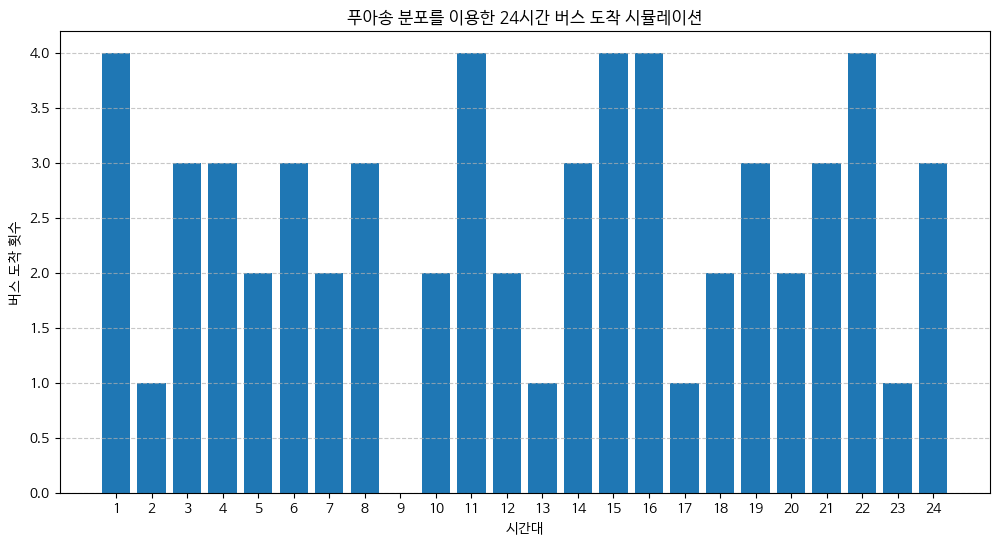

In [110]:
# 시뮬레이션: 하루(24시간) 동안의 버스 도착 패턴
np.random.seed(42)
hours = np.arange(1, 25)
arrivals = np.random.poisson(lambda_val, size=24)

plt.figure(figsize=(12, 6))
plt.bar(hours, arrivals)
plt.xlabel('시간대')
plt.ylabel('버스 도착 횟수')
plt.title('푸아송 분포를 이용한 24시간 버스 도착 시뮬레이션')
plt.xticks(hours)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

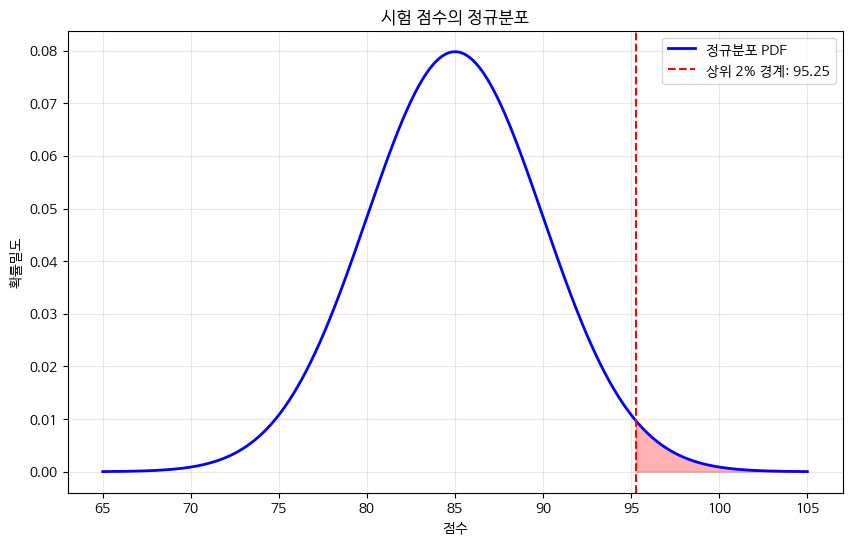

In [112]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 정규분포 예시 코드
mu = 85  # 평균
sigma = 5  # 표준편차

# 정규분포의 확률밀도함수
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
pdf = stats.norm.pdf(x, mu, sigma)

# 상위 2%에 해당하는 점수 계산
z_score = 2.05
critical_value = mu + z_score * sigma

# 시각화
plt.figure(figsize=(10, 6))
plt.plot(x, pdf, 'b-', lw=2, label='정규분포 PDF')
plt.axvline(critical_value, color='r', linestyle='--', label=f'상위 2% 경계: {critical_value:.2f}')
plt.fill_between(x, pdf, where=(x >= critical_value), alpha=0.3, color='r')

# 그래프 꾸미기
plt.title('시험 점수의 정규분포')
plt.xlabel('점수')
plt.ylabel('확률밀도')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

카이제곱 분포에서 적합도/독립성 검정<br>
H0 : 범주 간 차이가 없다<br>
H2 : 차이가 있다. 샘플링한 그룹에 편향이 있을 수 있다. 적합도가 떨어진다.<br>
<br>
카이제곱 통계량 > 관측값과 기대값과의 차이를 수치화<br>
<br>
p-value < 0.05 H0 기각, H1 채택<br>
값이 작을 수록 관측값이 기대값과 가깝다는 결론

이산확률분포
- 베르누이 : 성공|실패
- 이항분포 : 횟수, 성공의 횟수를 모델링
- 포아송분포 : 단위(시간/공간) 내에서 사건의 발생횟수를 모델링, 평균 발생률
- 기하분포, 초기하분포, 다항분포

연속확률분포

- 정규분포 : 평균 중심 - 좌우 대칭, 평균/표준편차
- 표준정규분포 : 평균0, 표준편차1인 정규분포 -> z점수로 확률값을 확인
- 카이제곱분포 : x의 제곱합, 분산을 분포화 - 적합도/동질성/분산(변동성), 자유도 > 정규분포화
- f분포 : 두 분산의 비율 비교, ANOVA(3개 이상 그룹의 분산 비교)

기계학습<br>
분류, 회귀 - 방정식 / 오차 > 정규 분포<br>
시뮬레이션 - x를 추출